In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load with error handling
# df = pd.read_csv("broken-csv.txt", on_bad_lines="skip"
# df = pd.read_csv("broken-csv.txt", on_bad_lines="skip")
df['email'] = df['email'].str.split(',').str[0]
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')
df['age'] = df['age'].fillna(df['age'].mean())
df.drop_duplicates(inplace=True)
df['name'] = df['name'].str.replace('"','')

In [22]:
# Make sure domain exists
df['domain'] = df['email'].str.split('@').str[1]
df

,id,name,email,signup_date,age,domain
0,1,Ada Lovelace,ada@example.org,2026-01-04,38.0,example.org
1,2,"Linus Torvalds, Jr.",linus@example.com,2026-01-05,54.0,example.com
2,3,Grace Hopper,grace@example.org,2026-01-06,41.0,example.org
3,4,"Margaret ""Hamilton""",margaret@example.com,2026-01-07,32.0,example.com
4,5,Alan Turing,"alan@example.com,backup@example.com",2026-01-08,29.0,"example.com,backup"
5,6,Edsger Dijkstra,edsger@example.org,not-a-date,57.0,example.org
6,7,"Ken,Thompson",ken@example.com,2026-01-10,NaN,example.com
7,8,Dennis Ritchie,dennis@example.org,2026-01-11,33.0,example.org
8,9,Donald Knuth,donald@example.org,2026-01-12,71.0,example.org
9,10,"Barbara ""Liskov",liskov@example.com,2026-01-13,28.0,example.com


In [28]:
# Step 2: Create helper columns
df['domain'] = df['email'].str.split('@').str[1]
df['year'] = df['signup_date'].dt.year
df['is_senior'] = df['age'].apply(lambda x: x > 50)
df

,id,name,email,signup_date,age,domain,year,is_senior
0,1,Ada Lovelace,ada@example.org,2026-01-04,38.000000,example.org,2026.0,False
1,2,"Linus Torvalds, Jr.",linus@example.com,2026-01-05,54.000000,example.com,2026.0,True
2,3,Grace Hopper,grace@example.org,2026-01-06,41.000000,example.org,2026.0,False
3,4,Margaret Hamilton,margaret@example.com,2026-01-07,32.000000,example.com,2026.0,False
4,5,Alan Turing,alan@example.com,2026-01-08,29.000000,example.com,2026.0,False
5,6,Edsger Dijkstra,edsger@example.org,NaT,57.000000,example.org,NaN,True
6,7,"Ken,Thompson",ken@example.com,2026-01-10,42.555556,example.com,2026.0,False
7,8,Dennis Ritchie,dennis@example.org,2026-01-11,33.000000,example.org,2026.0,False
8,9,Donald Knuth,donald@example.org,2026-01-12,71.000000,example.org,2026.0,True
9,10,Barbara Liskov,liskov@example.com,2026-01-13,28.000000,example.com,2026.0,False


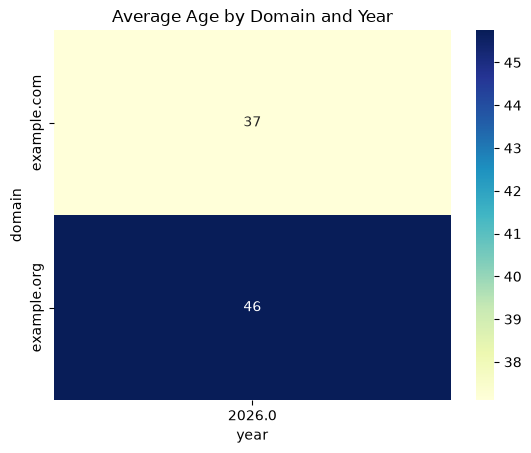

In [29]:
# Step 3: Pivot table for heatmap
pivot = pd.pivot_table(df, values='age', index='domain', columns='year', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap="YlGnBu")
plt.title("Average Age by Domain and Year")
plt.show()

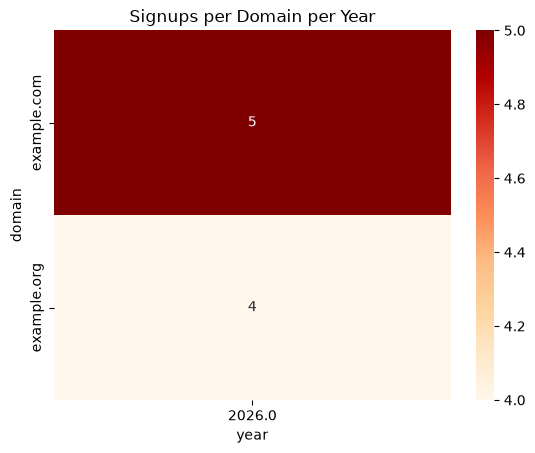

In [30]:
# Step 4: Crosstab for heatmap
crosstab = pd.crosstab(df['domain'], df['year'])
sns.heatmap(crosstab, annot=True, cmap="OrRd")
plt.title("Signups per Domain per Year")
plt.show()

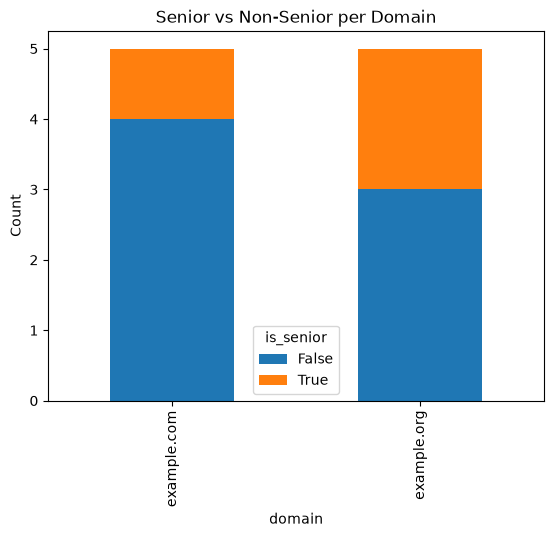

In [31]:
# Step 5: Stacked bar chart
grouped = df.groupby(['domain','is_senior']).size().unstack(fill_value=0)
grouped.plot(kind='bar', stacked=True)
plt.title("Senior vs Non-Senior per Domain")
plt.ylabel("Count")
plt.show()


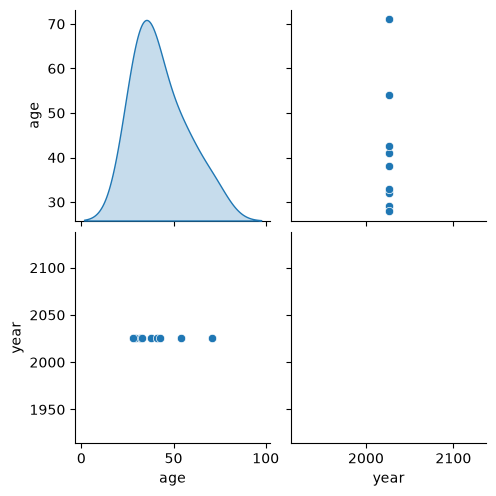

In [32]:

# Step 6: Pairplot for numeric relationships
sns.pairplot(df[['age','year']], diag_kind='kde')
plt.show()